# Testing Distance Scaling on Single Cell Data
We've confirmed the distance scaling function increases absolute differences between OT. Now, we want to see if this improves the ability of OT to differentiate between inter and intra celltype clustering.

## Imports

In [58]:
# Enabling fast reload
%load_ext autoreload
%autoreload 2

# Importing
import sys
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from pathlib import Path
sys.path.append('/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Scripts')
from hicdatautils import import_cool_dir, fetch_region, get_cool_name, bin_contact_map, hic_ot_source_to_targets, dist_weights

# Setting data directory
sc_dir = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Data/sc_data'
save_dir = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Generated Data/Single-to-single/sc_cell_type_clustering/ot'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Helper Functions

In [ ]:
def map_cell_types(data: pd.DataFrame, cell_type_map: pd.DataFrame):
    '''
        Transforms file name to file name comparisons in a pandas dataframe
        to a long format where each comparison has its own row, specifying inter
        or intra cell type of interest interactions.

        This function assusming formatting used in this notebook.

        Parameters
        ----------
        data : pd.DataFrame
            File name to file name dataframe of comparisons (SCC or OT).
        cell_type_map : pd.DataFrame
            Dataframe mapping file names to cell types.

        Returns
        -------
        data_long : pd.DataFrame
            A long format version of data with cell type information.
    '''

    # Mapping file to type
    type_lookup = cell_type_map.set_index("cell_name")["cell_type"]

    # Long format
    data_long = data.reset_index().rename(columns={"index": "row_file"})
    data_long = data_long.melt(id_vars="row_file",
                        var_name="col_file",
                        value_name="value")
    # Mapping celltypes
    data_long["row_cell_type"] = data_long["row_file"].map(type_lookup)
    data_long["col_cell_type"] = data_long["col_file"].map(type_lookup)

    # Inter and intra
    data_long["relationship"] = (
        data_long["row_cell_type"] == data_long["col_cell_type"]
        ).map({True: "intra", False: "inter"})

    return data_long

def generate_ot_data(source_cell_type: str, gamma: float=None, res: int=8, cell_count: int=20):
    '''
        Generates the OT data needed for the approach taken here

        This function is very specific to this notebook.

        Parameters
        ----------
        source_cell_type : str
            The cell type to be compared to all other cell types.
        gamma : float
            Distance scaling parameter.
            Default = None, uses no distance scaling.
        res : int
            Resolution to bin the data to in Mb.
            Default = 8.
        cell_count : int
            The top number of cells to be used.
            Default = 20.

        Returns
        -------
        ot_results_long : pd.DataFrame
            Long format pandas dataframe with the desired results.
    '''
    ### Importing Data ###    
    # Metadata
    metadata = pd.read_csv(sc_dir+"/cell_types.tsv", sep='\t')
    sampled_files = (
        metadata.groupby('cell_type')
                .apply(lambda x: x.sample(
                    n=min(len(x), cell_count),
                    replace=False,
                    random_state=42
                ))
                .reset_index(drop=True)
    )
    targets = list(sampled_files["cell_name"])
    sources = list(sampled_files[sampled_files["cell_type"] == source_cell_type]["cell_name"])

    # Coolers
    target_clrs = import_cool_dir(sc_dir, include=targets)
    source_clrs = import_cool_dir(sc_dir, include=sources)

    ### Performing OT ###
    # Saving directory
    ot_save_dir = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Generated Data/Single-to-single/sc_cell_type_clustering/ot'

    # Prepping data
    target_chr1s = []
    target_names = []

    for clr in target_clrs:
        target_chr1s.append(fetch_region(clr, "chr1"))
        target_names.append(get_cool_name(clr))

    source_chr1s = []
    source_names = []

    for clr in source_clrs:
        source_chr1s.append(fetch_region(clr, "chr1"))
        source_names.append(get_cool_name(clr))
    
    # Distance weighing
    if gamma is not None:
        target_chr1s_weighed = []
        for chr1 in target_chr1s:
            target_chr1s_weighed.append(dist_weights(chr1, gamma=gamma))

        source_chr1s_weighed = []
        for chr1 in source_chr1s:
            source_chr1s_weighed.append(dist_weights(chr1, gamma=gamma))
    else:
        target_chr1s_weighed = target_chr1s
        source_chr1s_weighed = source_chr1s


    # Binning
    target_chr1s_binned = []
    for chr1 in target_chr1s_weighed:
        target_chr1s_binned.append(bin_contact_map(chr1, res))

    source_chr1s_binned = []
    for chr1 in source_chr1s_weighed:
        source_chr1s_binned.append(bin_contact_map(chr1, res))

    # OT
    ot_results_list = []
    for map in source_chr1s_binned:
        ot_results_list.append(hic_ot_source_to_targets(map, target_chr1s_binned, 0, "raw", "sum"))

    # Transform to dataframe
    ot_results_df = pd.DataFrame(ot_results_list, index=source_names, columns=target_names)

    # Saving
    ot_results_df.to_csv(f'{ot_save_dir}/{source_cell_type}_type_clustering_ot_{res}mb_0_{cell_count}_γ={gamma}.csv')

    ### Transforming to long format ###
    ot_results_long = map_cell_types(ot_results_df, sampled_files)

    return ot_results_long

def load_ot_results_long(folder: str, res: int, thres: int, cell_count: int, gamma: float = None):
    '''
        Loads all csv files corresponding to OT results
        in the given folder.

        This function is very specific to this notebook.

        Parameters
        ----------
        folder : str
            Path to folder that is to be imported.
        res : int
            Resolution used for analysis.
        thres : int
            Threshold used for analysis.
        cell_count : int
            Number of cells used for analysis.
        gamma : float
            Distance scaling parameter.
            Default = None, looks for unscaled data.
        
        Returns
        -------
        ot_df_long : pd.Dataframe
            Long form dataframe with combined data from all
            OT results.
    '''
    folder = Path(folder)
    
    # Storage dictonary
    ot_dfs = []

    # Regex patterns
    cc = re.escape(str(cell_count))

    #if gamma is None:
    #    pattern = re.compile(
    #        rf"^(.*?)_type_clustering_ot_{res}mb_{thres}_{cell_count}\.csv$"
    #    )
    #else:
    pattern = re.compile(
        rf"^(.*?)_type_clustering_ot_{res}mb_{thres}_{cell_count}_γ={gamma}\.csv$"
    )

    for file in folder.glob("*.csv"):
        name = file.name

        m = pattern.match(name)
        if m:
            df = pd.read_csv(file, index_col=0)
            ot_dfs.append(df)

    # Covert to long and concatenate
    metadata = pd.read_csv(sc_dir+"/cell_types.tsv", sep='\t')
    ot_dfs_long = []
    for df in ot_dfs:
        ot_dfs_long.append(map_cell_types(df, metadata))
    
    ot_df_long = pd.concat(ot_dfs_long)

    return ot_df_long

def distribution_plot(data: pd.DataFrame, gamma: float, ax):
    '''
        Plots the distribution of the provided dataframe to
        the provided Axes object.

        Function is very specific to this notebook.

        Parameters
        ----------
        data : pd.DataFrame
            Data to be plotted.
        gamma : float
            Gamma value used to generate data.
        ax
            Axes object to plot to.
    '''
    # Setting order
    order = ["inter", "intra"]

    # Stripplot
    sns.stripplot(
    data=data,
    x="relationship",
    y="value",
    order=order,
    hue="relationship",
    dodge=False,
    jitter=True,
    alpha=0.05,
    palette={
        "inter": "#1f77b4",
        "intra": "#ff7f0e"
    },
    ax=ax
    )

    # Violin plot
    sns.violinplot(
        data=data,
        x="relationship",
        y="value",
        order=order,
        inner=None,
        color="lightgray",
        cut=0,
        ax=ax
    )

    ax.set_ylim(bottom=0, top=250)
    ax.set_ylabel("OT Loss")
    ax.set_title(f"γ={gamma}")
    return

## Generating Data

In [63]:
### 8 Mb, no threshold, gamma = 1.0 ###
    # Getting all cell types
metadata = pd.read_csv(sc_dir+"/cell_types.tsv", sep='\t')
cell_types = metadata["cell_type"].unique()

    # Setting parameters
gammas = np.arange(0.25, 2.01, 0.25)

for g in gammas:
    for ct in cell_types:
        generate_ot_data(ct, gamma=g, cell_count=5)

    # Generating unscaled data
for ct in cell_types:
        generate_ot_data(ct, gamma=None, cell_count=5)

/var/folders/pf/6xtc7fx5435c3f0dbwrdl5tc0000gn/T/ipykernel_35835/3383966950.py:71: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(
/var/folders/pf/6xtc7fx5435c3f0dbwrdl5tc0000gn/T/ipykernel_35835/3383966950.py:71: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(
/var/folders/pf/6xtc7fx5435c3f0dbwrdl5tc0000gn/T/ipykernel_35835/3383966950.py:71: FutureWarning: DataFrameG

## Loading Data

In [67]:
### Loading data ###
ot_8mb_0 = {}

    # Loading gamma=None
ot_8mb_0[None] = load_ot_results_long(save_dir, 8, 0, 5, None)

    # Loading other gammas
for g in gammas:
    ot_8mb_0[g] = load_ot_results_long(save_dir, 8, 0, 5, g)

## Graphing Data

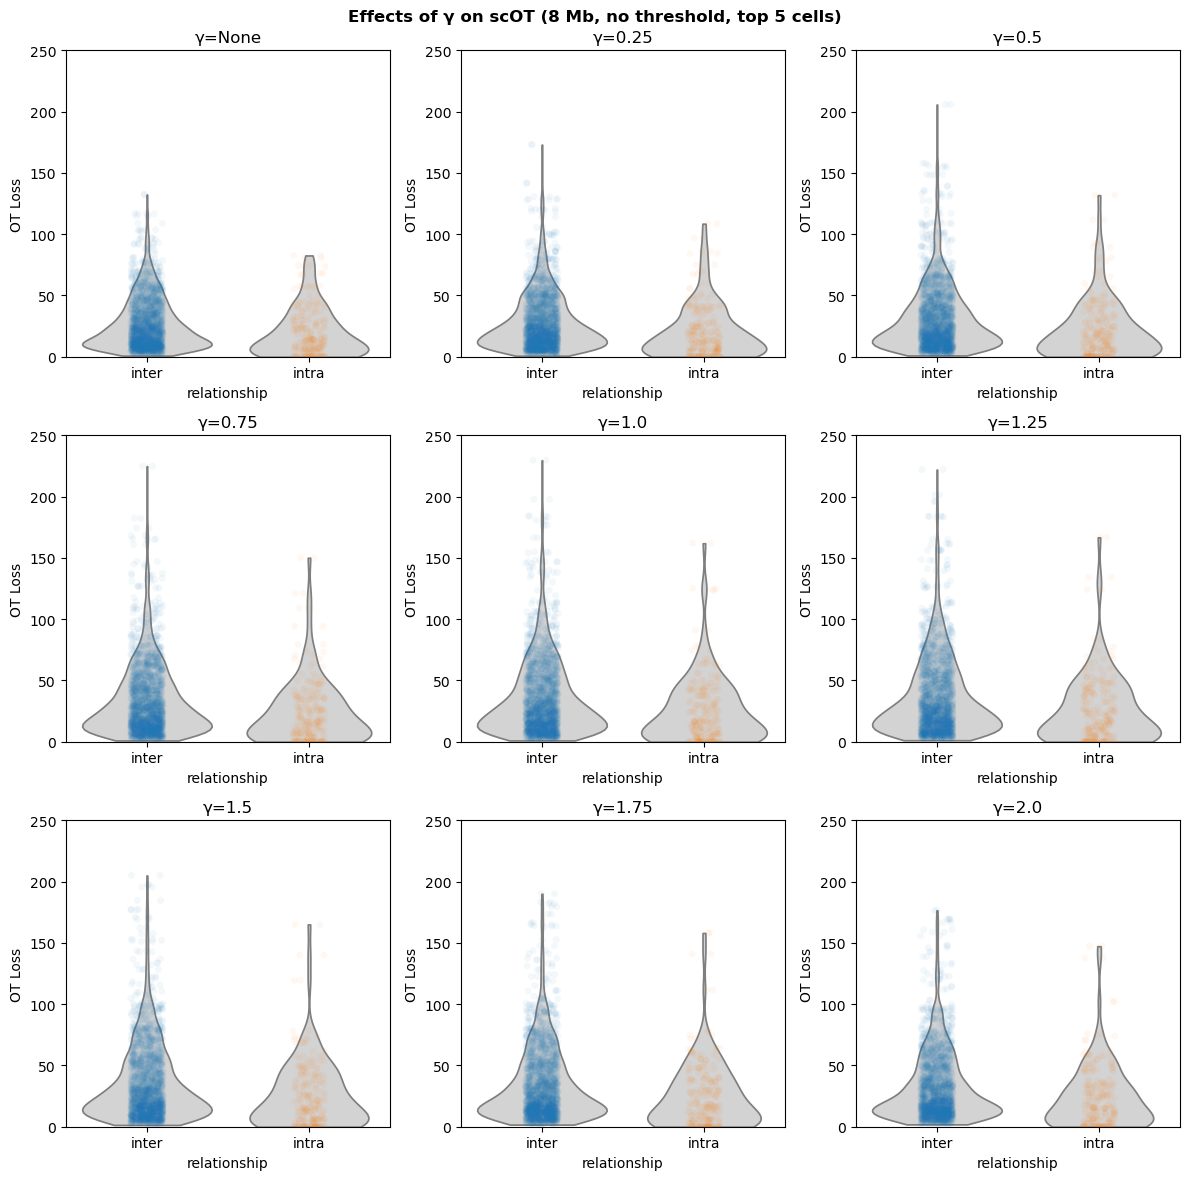

In [91]:
### 8 Mb, no threshold ###
fig, ax = plt.subplots(3, 3, figsize=(12, 12))

axes = ax.flatten()

for i, (g, data) in enumerate(ot_8mb_0.items()):
    distribution_plot(data, g, axes[i])
plt.suptitle("Effects of γ on scOT (8 Mb, no threshold, top 5 cells)", fontweight="bold")
plt.tight_layout()